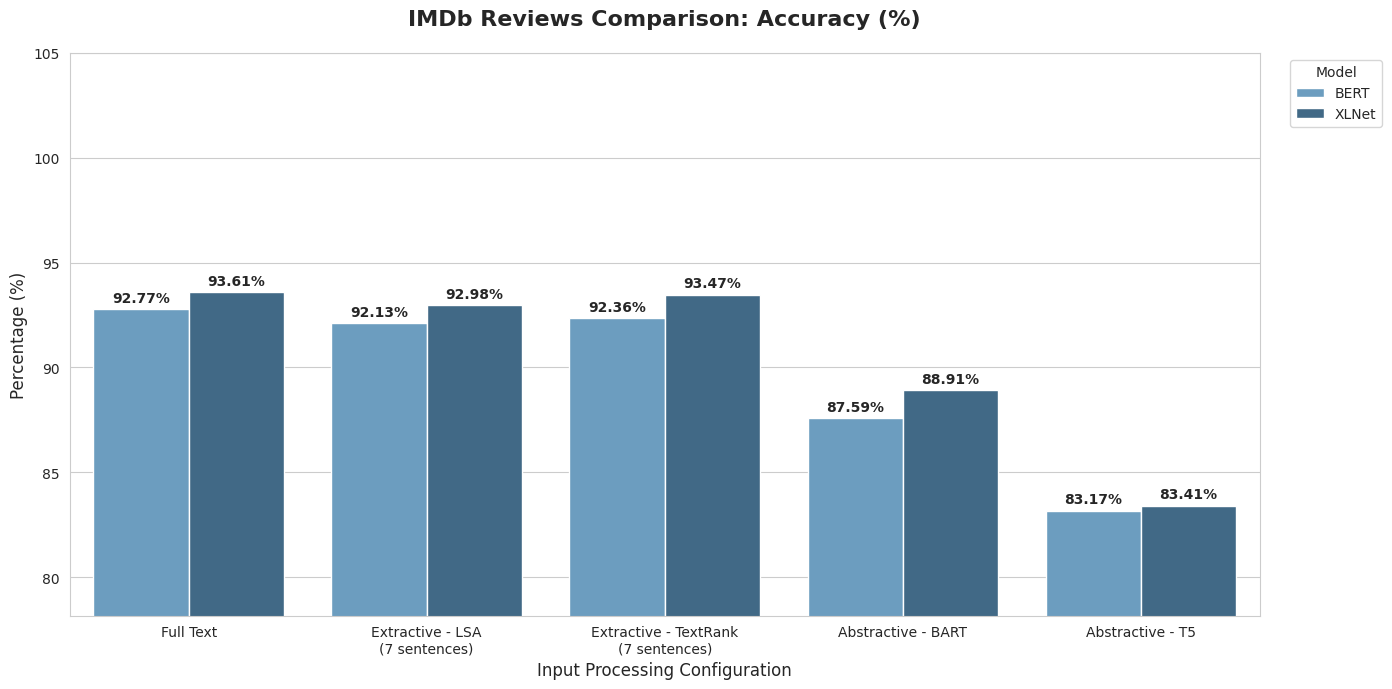

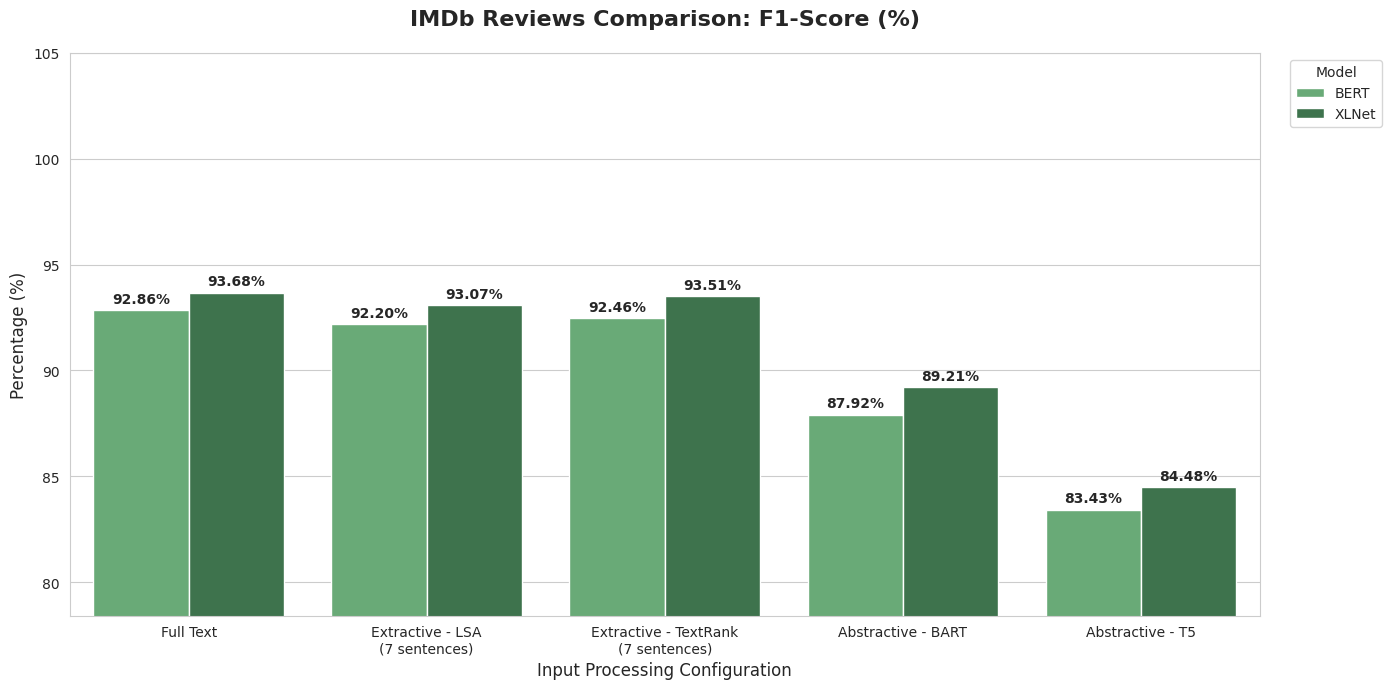

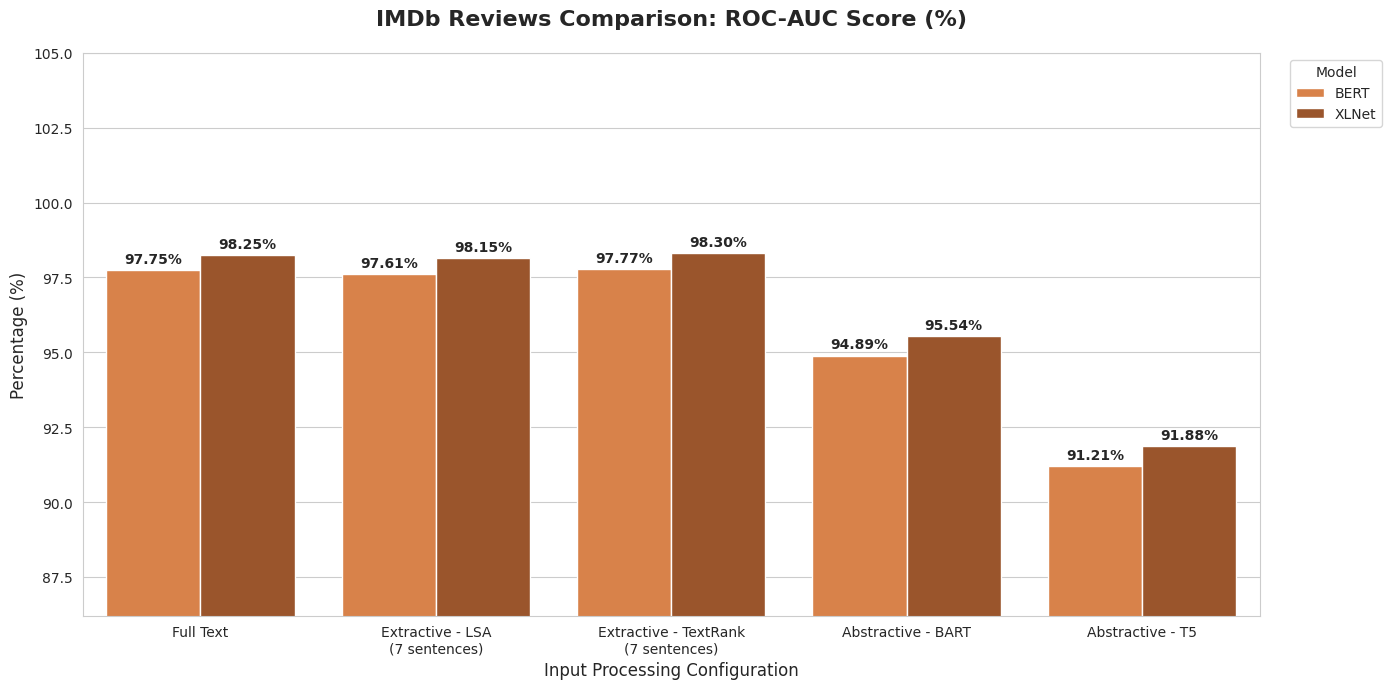

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Prepare the Data
data = {
    'Input Type': [
        'Full Text', 'Full Text',
        'Extractive - LSA', 'Extractive - LSA',
        'Extractive - TextRank', 'Extractive - TextRank',
        'Abstractive - BART', 'Abstractive - BART',
        'Abstractive - T5', 'Abstractive - T5'
    ],
    'Config': [
        '—', '—', '7 sentences', '7 sentences',
        '7 sentences', '7 sentences', '—', '—', '—', '—'
    ],
    'Model': ['BERT', 'XLNet', 'BERT', 'XLNet', 'BERT', 'XLNet', 'BERT', 'XLNet', 'BERT', 'XLNet'],
    'Accuracy': [0.9277, 0.9361, 0.9213, 0.9298, 0.9236, 0.9347, 0.8759, 0.8891, 0.8317, 0.8341],
    'F1-score': [0.9286, 0.9368, 0.9220, 0.9307, 0.9246, 0.9351, 0.8792, 0.8921, 0.8343, 0.8448],
    'Roc-auc': [0.9775, 0.9825, 0.9761, 0.9815, 0.9777, 0.9830, 0.9489, 0.9554, 0.9121, 0.9188]
}

df = pd.DataFrame(data)

# Convert metrics to percentages
metrics = ['Accuracy', 'F1-score', 'Roc-auc']
for m in metrics:
    df[m] = df[m] * 100

# Format X-axis labels to include the '7 sentences' configuration
df['Label'] = df.apply(
    lambda x: f"{x['Input Type']}\n({x['Config']})" if x['Config'] != '—' else x['Input Type'],
    axis=1
)

# 2. Plotting Function
def create_imdb_plot(metric, title, palette):
    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")

    ax = sns.barplot(data=df, x='Label', y=metric, hue='Model', palette=palette)

    plt.title(f'IMDb Reviews Comparison: {title} (%)', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xlabel('Input Processing Configuration', fontsize=12)

    # Set Y-axis to focus on the performance range
    plt.ylim(df[metric].min() - 5, 105)

    # Add labels with 2 decimal place precision
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=10, fontweight='bold')

    plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# 3. Generate Visualizations
create_imdb_plot('Accuracy', 'Accuracy', 'Blues_d')
create_imdb_plot('F1-score', 'F1-Score', 'Greens_d')
create_imdb_plot('Roc-auc', 'ROC-AUC Score', 'Oranges_d')

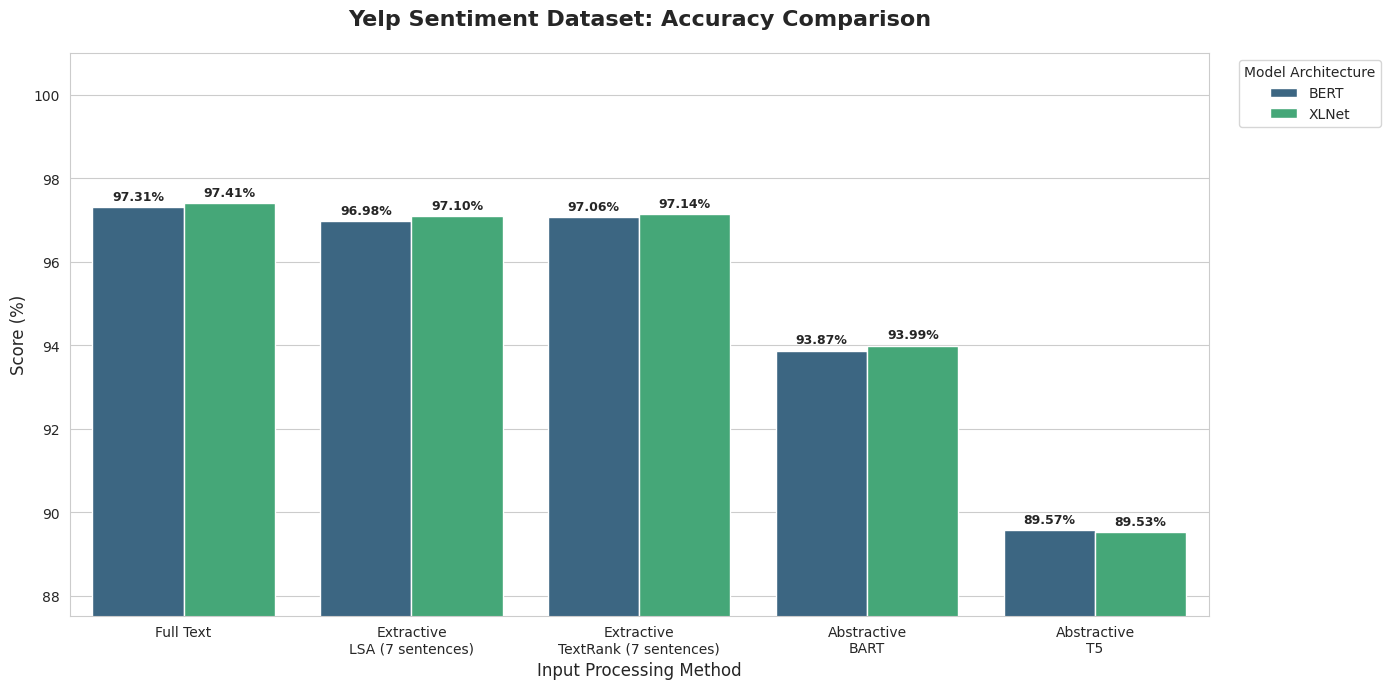

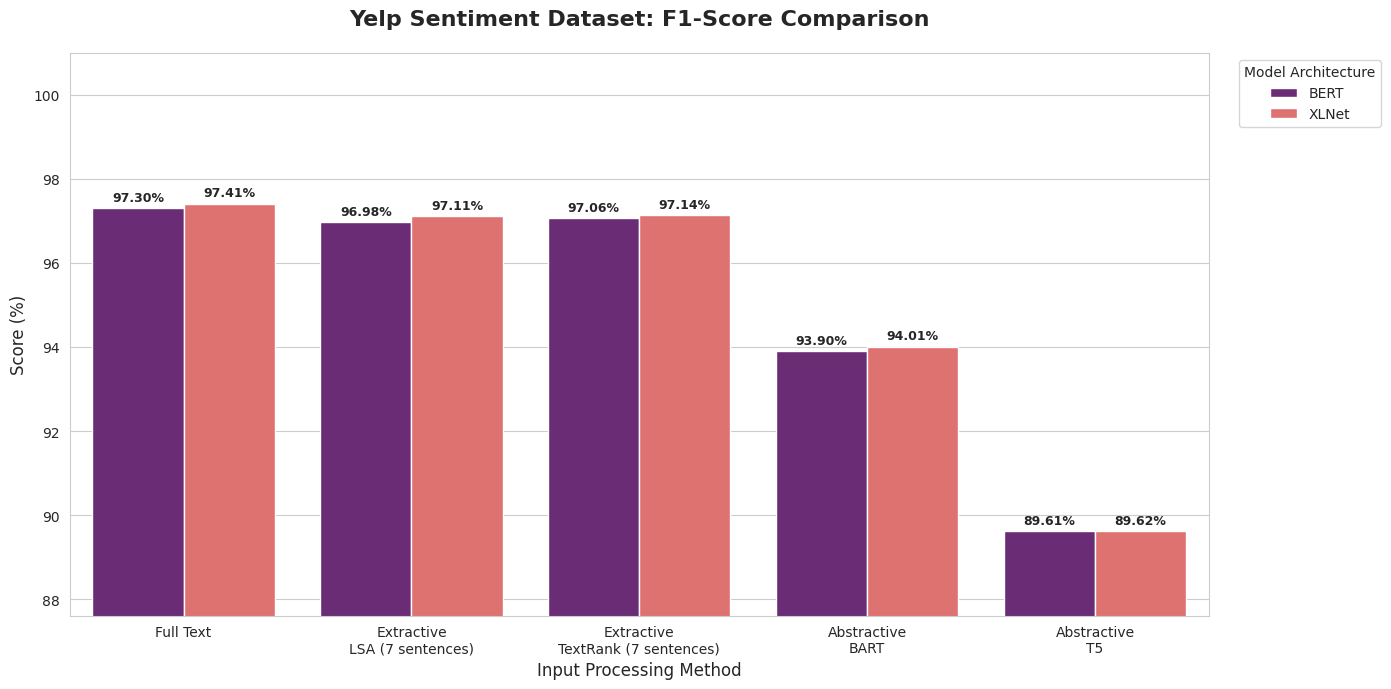

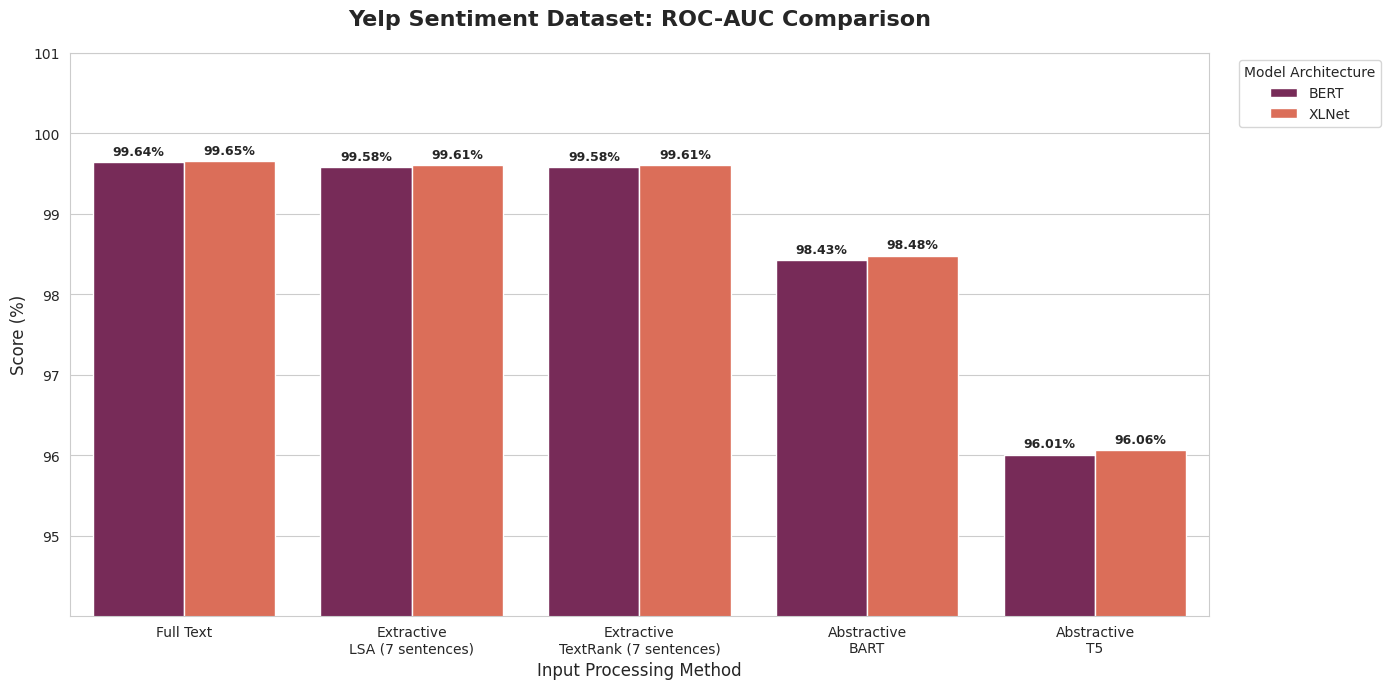

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Data Setup for Yelp Sentiment Dataset
data = {
    'Input Representation': [
        'Full Text', 'Full Text',
        'Extractive - LSA (7 sentences)', 'Extractive - LSA (7 sentences)',
        'Extractive - TextRank (7 sentences)', 'Extractive - TextRank (7 sentences)',
        'Abstractive - BART', 'Abstractive - BART',
        'Abstractive - T5', 'Abstractive - T5'
    ],
    'Model': ['BERT', 'XLNet', 'BERT', 'XLNet', 'BERT', 'XLNet', 'BERT', 'XLNet', 'BERT', 'XLNet'],
    'Accuracy': [0.9731, 0.9741, 0.9698, 0.9710, 0.9706, 0.9714, 0.9387, 0.9399, 0.8957, 0.8953],
    'F1-score': [0.9730, 0.9741, 0.9698, 0.9711, 0.9706, 0.9714, 0.9390, 0.9401, 0.8961, 0.8962],
    'ROC-AUC': [0.9964, 0.9965, 0.9958, 0.9961, 0.9958, 0.9961, 0.9843, 0.9848, 0.9601, 0.9606]
}

df = pd.DataFrame(data)

# Convert to percentages for readability
for metric in ['Accuracy', 'F1-score', 'ROC-AUC']:
    df[metric] = df[metric] * 100

# Format X-axis labels for multi-line display
df['Display Label'] = df['Input Representation'].str.replace(' - ', '\n')

def create_yelp_plot(metric_col, title, palette):
    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")

    # Create the bar plot
    ax = sns.barplot(data=df, x='Display Label', y=metric_col, hue='Model', palette=palette)

    # Title and Labels
    plt.title(f'Yelp Sentiment Dataset: {title} Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Score (%)', fontsize=12)
    plt.xlabel('Input Processing Method', fontsize=12)

    # Set Y-axis limit slightly below the minimum value for better visual contrast
    min_val = df[metric_col].min()
    plt.ylim(min_val - 2, 101)

    # Add precise data labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=9, fontweight='bold')

    plt.legend(title='Model Architecture', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# 2. Generate the Visualizations
create_yelp_plot('Accuracy', 'Accuracy', 'viridis')
create_yelp_plot('F1-score', 'F1-Score', 'magma')
create_yelp_plot('ROC-AUC', 'ROC-AUC', 'rocket')